In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("cleaned_movie_data.csv")

In [41]:
print("actor_1_facebook_likes" in df.columns)

True


In [42]:
df.shape

(4998, 28)

In [43]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes,classify
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000,hit
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0,hit
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000,hit
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000,hit
4,unknown,Doug Walker,110.0,103.0,131.0,369.0,Rob Walker,131.0,25445749.0,Documentary,...,unknown,unknown,unknown,20000000.0,2005.0,12.0,7.1,2.35,0,hit


In [44]:
df.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'num_user_for_reviews', 'language', 'country', 'content_rating',
       'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score',
       'aspect_ratio', 'movie_facebook_likes', 'classify'],
      dtype='str')

Feature Selection and Model Preparation

the `imdb_score` feature is excluded from the input features because it was directly used to create the target variable. Including IMDb score would cause target leakage and could lead to unrealistically high model performance.
Other movie attributes are evaluated based on their relevance, multicollinearity, and suitability for machine learning.


In [45]:
#Correlation Analysis
numerical_data = df.select_dtypes(include=["int64", "float64"])


In [46]:
numerical_data.columns

Index(['num_critic_for_reviews', 'duration', 'director_facebook_likes',
       'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross',
       'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster',
       'num_user_for_reviews', 'budget', 'title_year',
       'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio',
       'movie_facebook_likes'],
      dtype='str')

In [47]:
correlation_matrix = numerical_data.corr()
correlation_matrix

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
num_critic_for_reviews,1.000000,0.256559,0.184209,0.265809,0.190535,0.483561,0.624406,0.261421,-0.035230,0.608311,0.120792,0.267930,0.281016,0.304409,-0.054082,0.681953
duration,0.256559,1.000000,0.161753,0.119986,0.087899,0.228702,0.314052,0.121062,0.013649,0.328023,0.069039,-0.129163,0.130062,0.261911,-0.090260,0.194524
director_facebook_likes,0.184209,0.161753,1.000000,0.124061,0.092877,0.147172,0.300739,0.122214,-0.040959,0.225152,0.022664,-0.065776,0.122487,0.163552,-0.015802,0.162575
actor_3_facebook_likes,0.265809,0.119986,0.124061,1.000000,0.250170,0.298288,0.278107,0.470094,0.098782,0.226230,0.047428,0.094088,0.556436,0.051290,-0.004850,0.267916
actor_1_facebook_likes,0.190535,0.087899,0.092877,0.250170,1.000000,0.153813,0.191484,0.952756,0.071068,0.145467,0.024374,0.084299,0.389904,0.075717,-0.019896,0.133759
gross,0.483561,0.228702,0.147172,0.298288,0.153813,1.000000,0.637578,0.239505,-0.027271,0.566657,0.111336,0.039019,0.265086,0.174612,-0.013029,0.376811
num_voted_users,0.624406,0.314052,0.300739,0.278107,0.191484,0.637578,1.000000,0.261063,-0.029741,0.798699,0.082423,0.005485,0.265560,0.411299,-0.018002,0.535218
cast_total_facebook_likes,0.261421,0.121062,0.122214,0.470094,0.952756,0.239505,0.261063,1.000000,0.089485,0.205013,0.037880,0.107341,0.625911,0.085091,-0.018641,0.204378
facenumber_in_poster,-0.035230,0.013649,-0.040959,0.098782,0.071068,-0.027271,-0.029741,0.089485,1.000000,-0.070208,-0.019212,0.060500,0.069546,-0.064120,0.013383,0.006175
num_user_for_reviews,0.608311,0.328023,0.225152,0.226230,0.145467,0.566657,0.798699,0.205013,-0.070208,1.000000,0.087734,-0.005172,0.217713,0.291078,-0.028407,0.399089


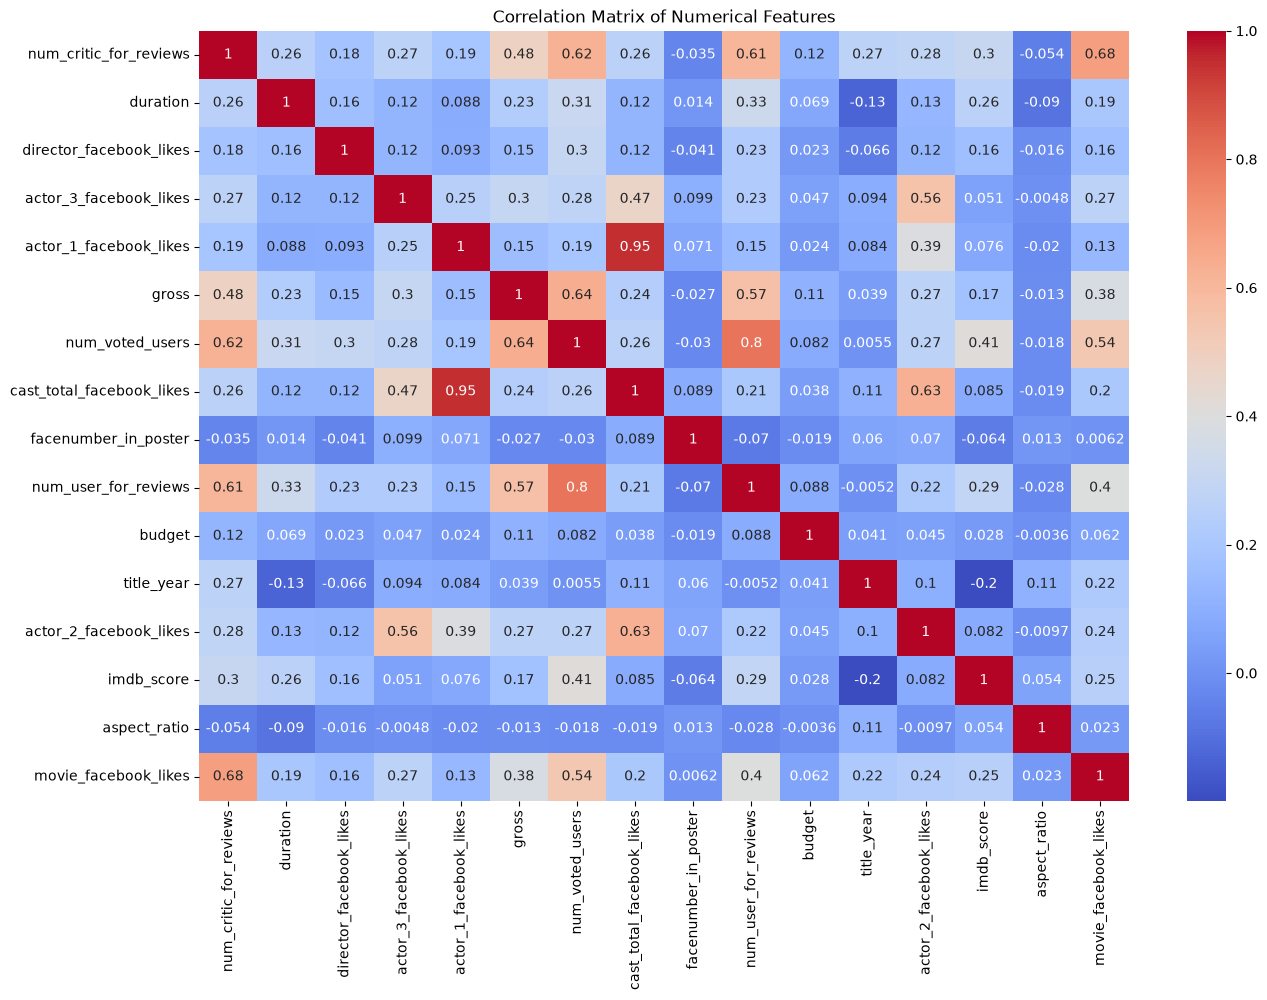

In [48]:
plt.figure(figsize=(15, 10))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix of Numerical Features")

plt.show()

**Observation:** The correlation heatmap shows that most numerical features have low to moderate correlations. A very strong positive correlation of approximately 0.95 is observed between `actor_1_facebook_likes` and `cast_total_facebook_likes`, indicating possible multicollinearity. A strong correlation of approximately 0.80 is also observed between `num_voted_users` and `num_user_for_reviews`. Other numerical features mainly show low to moderate correlations.

In [49]:
# Handling Multicollinearity
df.drop("actor_1_facebook_likes", axis=1, inplace=True)

In [50]:
df.shape

(4998, 27)

In [51]:
df.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'gross', 'genres', 'actor_1_name', 'movie_title', 'num_voted_users',
       'cast_total_facebook_likes', 'actor_3_name', 'facenumber_in_poster',
       'plot_keywords', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes', 'classify'],
      dtype='str')

In [52]:
#Creating Input Features and Target Variable:
X = df.drop(["classify","imdb_score","movie_title"], axis=1)
y = df["classify"]

In [53]:
X.shape

(4998, 24)

In [54]:
y.shape

(4998,)

In [55]:
X.dtypes

color                            str
director_name                    str
num_critic_for_reviews       float64
duration                     float64
director_facebook_likes      float64
actor_3_facebook_likes       float64
actor_2_name                     str
gross                        float64
genres                           str
actor_1_name                     str
num_voted_users                int64
cast_total_facebook_likes      int64
actor_3_name                     str
facenumber_in_poster         float64
plot_keywords                    str
num_user_for_reviews         float64
language                         str
country                          str
content_rating                   str
budget                       float64
title_year                   float64
actor_2_facebook_likes       float64
aspect_ratio                 float64
movie_facebook_likes           int64
dtype: object

In [56]:
#Encoding Categorical Variables
from sklearn.preprocessing import LabelEncoder

In [57]:
#Identify categorical columns
categorical_columns = X.select_dtypes(include=["object","str"]).columns

In [58]:
categorical_columns

Index(['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name',
       'actor_3_name', 'plot_keywords', 'language', 'country',
       'content_rating'],
      dtype='str')

In [59]:
#Label Encoding
le = LabelEncoder()
for columns in categorical_columns:
    X[columns] =le.fit_transform(X[columns])

In [60]:
X.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,gross,genres,actor_1_name,...,plot_keywords,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,aspect_ratio,movie_facebook_likes
0,1,922,723.0,178.0,0.0,855.0,1405,760505847.0,106,264,...,1318,3054.0,11,62,7,237000000.0,2009.0,936.0,1.78,33000
1,1,794,302.0,169.0,563.0,1000.0,2216,309404152.0,100,976,...,4281,1238.0,11,62,7,300000000.0,2007.0,5000.0,2.35,0
2,1,2021,602.0,148.0,0.0,161.0,2487,200074175.0,127,349,...,2078,994.0,11,61,7,245000000.0,2015.0,393.0,2.35,85000
3,1,373,813.0,164.0,22000.0,23000.0,532,448130642.0,287,1963,...,3482,2701.0,11,62,7,250000000.0,2012.0,23000.0,2.35,164000
4,2,600,110.0,103.0,131.0,369.0,2431,25445749.0,753,522,...,4757,156.0,46,65,18,20000000.0,2005.0,12.0,2.35,0


In [61]:
X.dtypes

color                          int64
director_name                  int64
num_critic_for_reviews       float64
duration                     float64
director_facebook_likes      float64
actor_3_facebook_likes       float64
actor_2_name                   int64
gross                        float64
genres                         int64
actor_1_name                   int64
num_voted_users                int64
cast_total_facebook_likes      int64
actor_3_name                   int64
facenumber_in_poster         float64
plot_keywords                  int64
num_user_for_reviews         float64
language                       int64
country                        int64
content_rating                 int64
budget                       float64
title_year                   float64
actor_2_facebook_likes       float64
aspect_ratio                 float64
movie_facebook_likes           int64
dtype: object

Train-Test Split:

The dataset is divided into training and testing sets to evaluate the model's ability to make predictions on unseen data.
80% of the data is used for model training and 20% is used for model testing. Stratified sampling is used to maintain the proportion of Hit, Average, and Flop movies in both datasets.

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42,stratify=y)

In [64]:
X_train.shape

(3998, 24)

In [65]:
X_test.shape

(1000, 24)

In [66]:
y_train.shape

(3998,)

In [67]:
y_test.shape

(1000,)

In [68]:
y_train.value_counts()

classify
hit        2844
average    1121
flop         33
Name: count, dtype: int64

In [69]:
y_test.value_counts()

classify
hit        712
average    280
flop         8
Name: count, dtype: int64

**Observation:** The dataset was successfully divided into 80% training data and 20% testing data. The training set contains 3,998 observations and the testing set contains 1,000 observations. Stratified sampling maintained similar proportions of Hit, Average, and Flop movies in both datasets. However, the Flop category remains highly underrepresented, confirming the class imbalance identified during EDA.

In [70]:
#Feature Scaling:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [71]:
X_train_scaled

array([[ 0.17601638,  0.18330915,  0.19321493, ..., -0.15347143,
         0.10090788, -0.39834851],
       [ 0.17601638,  1.36013824, -0.57480715, ..., -0.17806805,
         0.10090788, -0.36499956],
       [ 0.17601638,  0.18330915,  1.68796759, ..., -0.15347143,
         0.10090788,  0.40202617],
       ...,
       [ 0.17601638,  0.61598763,  0.8951706 , ...,  2.25796167,
         0.10090788, -0.39834851],
       [ 0.17601638, -1.69257052,  1.91920004, ..., -0.29092312,
        -0.28654334,  0.50874279],
       [ 0.17601638, -1.08653877, -0.01324261, ...,  1.77567505,
         0.10090788, -0.39834851]], shape=(3998, 24))

**Observation:** StandardScaler successfully transformed the input features onto a comparable scale. The scaled training dataset contains 3,998 observations and 24 features. The transformed values are centered around zero, where positive values represent observations above the feature mean and negative values represent observations below the feature mean.